# Game 2 - The Data Reconnaissance Mission

**Team:** Ded_Sec

This notebook loads the full measured statistics, compares Train and
Validation, visualizes major distributions, and prioritizes risks without
changing the source data.


In [1]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(os.environ.get("AIO_ROOT", r"C:\Users\mohd1\OneDrive\Desktop\ai olpyc\AI_Olympics_2026_Student_Release_v1"))
OUTPUT_DIR = Path.cwd()

train_text = pd.read_csv(OUTPUT_DIR / "game2_train_text_statistics.csv")
validation_text = pd.read_csv(OUTPUT_DIR / "game2_validation_text_statistics.csv")
train_images = pd.read_csv(OUTPUT_DIR / "game2_train_image_statistics.csv")
validation_images = pd.read_csv(OUTPUT_DIR / "game2_validation_image_statistics.csv")
risks = pd.read_csv(OUTPUT_DIR / "game2_risk_priority_table.csv")

print("Train rows:", len(train_text))
print("Validation rows:", len(validation_text))
display(risks)


Train rows: 9000
Validation rows: 2500


,risk_id,modality,discovered_pattern,evidence,affected_split,affected_samples,severity,recommended_next_action
0,R01,label,Training class imbalance,"Train counts={'fake': 5000, 'real': 4000}; val...",train,1000,high,Use stratification and test class-weighted los...
1,R02,text,Missing or empty text,100 empty texts; label distribution={'fake': 5...,train,100,high,"Preserve rows, add a missing-text indicator, a..."
2,R03,text,High symbol ratio,2 rows have symbol_ratio > 0.20,train,2,medium,Test conservative punctuation normalization wh...
3,R04,text,Missing or empty text,30 empty texts; label distribution={'fake': 17...,validation,30,high,"Preserve rows, add a missing-text indicator, a..."
4,R05,image,Altered images mixed with original-quality images,"modified=475 (train=380, validation=95); media...",both,475,high,Audit alteration types and test quality-robust...
5,R06,image,Low-resolution images,962 images have width or height below 128 pixels,both,962,high,Use aspect-preserving resize with padding; avo...
6,R07,image,Extreme aspect ratios,75 images fall outside the 0.5-2.0 aspect-rati...,both,75,medium,Use padding or center-crop experiments and com...
7,R08,image,Very low sharpness tail,575 images are at or below the 5th-percentile ...,both,575,medium,Test mild sharpening only as a controlled expe...
8,R09,image,Extreme brightness,238 images have mean brightness below 30 or ab...,both,238,medium,Test bounded contrast normalization and compar...


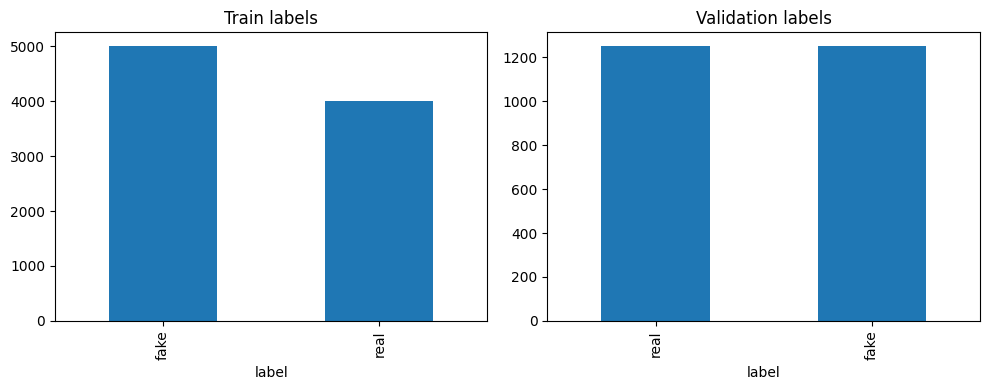

,train,validation
text_length_chars,122.400667,123.745200
text_length_words,19.584111,19.918400
symbol_ratio,0.026944,0.026783


Empty train texts: 100
Empty validation texts: 30


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train_text["label"].value_counts().plot.bar(ax=axes[0], title="Train labels")
validation_text["label"].value_counts().plot.bar(
    ax=axes[1], title="Validation labels"
)
plt.tight_layout()
plt.show()

display(
    pd.DataFrame({
        "train": train_text[[
            "text_length_chars", "text_length_words", "symbol_ratio"
        ]].mean(),
        "validation": validation_text[[
            "text_length_chars", "text_length_words", "symbol_ratio"
        ]].mean(),
    })
)
print("Empty train texts:", int(train_text["is_empty_text"].sum()))
print("Empty validation texts:", int(validation_text["is_empty_text"].sum()))


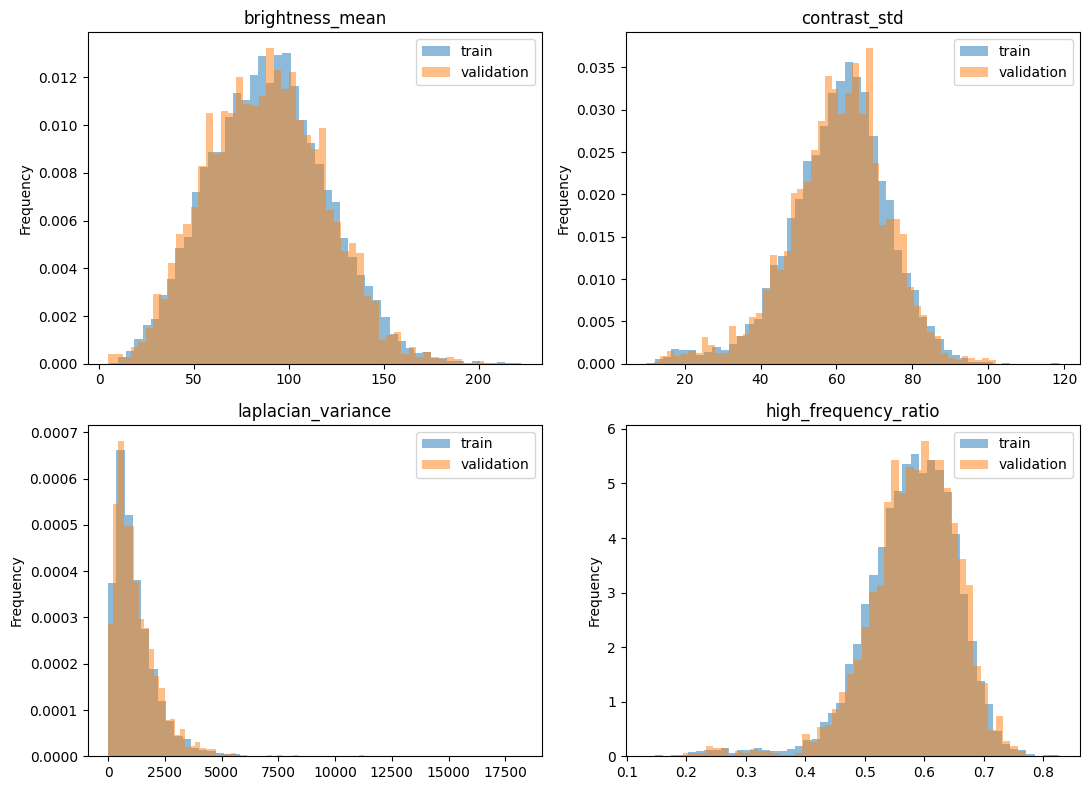

,brightness_mean,contrast_std,laplacian_variance,high_frequency_ratio,width,height,file_size_kb
image_source,,,,,,,
modified,77.403519,43.833401,84.421165,0.476715,600.0,390.0,28.848633
shared,89.005280,61.790455,1001.066772,0.587224,600.0,400.0,65.177734


,risk_id,modality,discovered_pattern,evidence,affected_split,affected_samples,severity,recommended_next_action
0,R01,label,Training class imbalance,"Train counts={'fake': 5000, 'real': 4000}; val...",train,1000,high,Use stratification and test class-weighted los...
1,R02,text,Missing or empty text,100 empty texts; label distribution={'fake': 5...,train,100,high,"Preserve rows, add a missing-text indicator, a..."
3,R04,text,Missing or empty text,30 empty texts; label distribution={'fake': 17...,validation,30,high,"Preserve rows, add a missing-text indicator, a..."
4,R05,image,Altered images mixed with original-quality images,"modified=475 (train=380, validation=95); media...",both,475,high,Audit alteration types and test quality-robust...
5,R06,image,Low-resolution images,962 images have width or height below 128 pixels,both,962,high,Use aspect-preserving resize with padding; avo...
2,R03,text,High symbol ratio,2 rows have symbol_ratio > 0.20,train,2,medium,Test conservative punctuation normalization wh...
6,R07,image,Extreme aspect ratios,75 images fall outside the 0.5-2.0 aspect-rati...,both,75,medium,Use padding or center-crop experiments and com...
7,R08,image,Very low sharpness tail,575 images are at or below the 5th-percentile ...,both,575,medium,Test mild sharpening only as a controlled expe...
8,R09,image,Extreme brightness,238 images have mean brightness below 30 or ab...,both,238,medium,Test bounded contrast normalization and compar...


In [3]:
metrics = [
    "brightness_mean",
    "contrast_std",
    "laplacian_variance",
    "high_frequency_ratio",
]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, metric in zip(axes.flat, metrics):
    train_images[metric].plot.hist(
        bins=50, alpha=0.5, density=True, ax=ax, label="train"
    )
    validation_images[metric].plot.hist(
        bins=50, alpha=0.5, density=True, ax=ax, label="validation"
    )
    ax.set_title(metric)
    ax.legend()
plt.tight_layout()
plt.show()

display(
    pd.concat([train_images, validation_images])
    .groupby("image_source")[metrics + ["width", "height", "file_size_kb"]]
    .median()
)
display(risks.sort_values(["severity", "risk_id"]))


## Final Conclusion

The dataset is not ready for modeling without controlled preprocessing experiments. The highest-priority risks are: Training class imbalance; Missing or empty text; Missing or empty text; Altered images mixed with original-quality images; Low-resolution images. Images and texts require separate quality indicators, and train and validation must receive identical transformations. Game 3 should test conservative changes one at a time while preserving originals.
